# Preprocessing: Dataset Roboflow `Malocclusion-Data`

Notebook ini membangun dataset COCO baru yang sudah dipreprocess dari `Dataset/Malocclusion-Data-1/` (dataset asli, tidak diubah) ke `Dataset/Malocclusion-Data-processed/`. Berdasarkan temuan EDA di `02_roboflow_malocclusion_eda.ipynb`, langkah yang diterapkan di sini:

1. **Perbaiki split** — 14 dari 30 kelas sama sekali tidak punya instance di `valid`, dan tidak ada `test` sama sekali. Train+valid dipool ulang lalu displit ulang dengan **stratifikasi greedy per-kelas** (bukan random murni) supaya tiap kelas punya representasi di setiap split, sejauh jumlah instance-nya memungkinkan.
2. **Auto-orient** — normalisasi rotasi EXIF (sudah dicek: dari 626 gambar, tidak ada yang punya EXIF orientation non-default, jadi langkah ini aman/no-op untuk data saat ini, tapi tetap disertakan sebagai jaring pengaman).
3. **Resize + letterbox** ke ukuran seragam 800×800 (gambar aslinya sangat bervariasi: 188 kombinasi resolusi, 3456×2435 s/d 6240×6000) — bbox ikut ditransformasi mengikuti scale + offset padding.

**Sengaja belum dikerjakan di notebook ini** (sesuai kesepakatan): horizontal flip augmentation (perlu verifikasi dulu apakah kode kelas encode sisi kiri/kanan) dan augmentasi lain (rotasi, brightness, dst). Rencana: coba training dulu di atas data "base" hasil notebook ini (split sudah benar + resize seragam, tanpa augmentasi), baru evaluasi apakah augmentasi diperlukan.

## 1. Setup

In [1]:
import json
import random
from pathlib import Path
from collections import defaultdict

import pandas as pd
from PIL import Image, ImageOps, ImageDraw
import matplotlib.pyplot as plt

SRC = Path("../Dataset/Malocclusion-Data-1")
DST = Path("../Dataset/Malocclusion-Data-processed")
OLD_SPLITS = ["train", "valid"]
NEW_SPLITS = ["train", "valid", "test"]
TARGET_SIZE = 800
TARGET_RATIO = {"train": 0.75, "valid": 0.15, "test": 0.10}
RNG_SEED = 42

DST.mkdir(parents=True, exist_ok=True)
for split in NEW_SPLITS:
    (DST / split).mkdir(parents=True, exist_ok=True)


## 2. Pool gambar & anotasi dari `train` + `valid` lama

Kita gabung dulu semua gambar dari kedua split lama sebelum displit ulang, supaya distribusi kelas bisa diatur ulang secara sadar (bukan cuma nurunin apa yang sudah ada). ID gambar/anotasi dibuat ulang supaya unik secara global (ID lama antar split bisa bentrok karena Roboflow reset ID per split).

In [2]:
raw = {}
for split in OLD_SPLITS:
    with open(SRC / split / "_annotations.coco.json") as f:
        raw[split] = json.load(f)

categories = [c for c in raw["train"]["categories"] if c["supercategory"] != "none"]
categories_full = raw["train"]["categories"]  # termasuk placeholder root, dipertahankan untuk kompatibilitas COCO standar
cat_id_to_name = {c["id"]: c["name"] for c in categories}

pool_images = {}
pool_annotations = []
img_counter = 0
ann_counter = 0
old_id_to_new = {}

for split in OLD_SPLITS:
    for img in raw[split]["images"]:
        new_id = img_counter
        img_counter += 1
        old_id_to_new[(split, img["id"])] = new_id
        rec = dict(img)
        rec["_src_split"] = split
        rec["_src_file"] = SRC / split / img["file_name"]
        rec["id"] = new_id
        pool_images[new_id] = rec

    for ann in raw[split]["annotations"]:
        a = dict(ann)
        a["id"] = ann_counter
        ann_counter += 1
        a["image_id"] = old_id_to_new[(split, ann["image_id"])]
        a["category_name"] = cat_id_to_name.get(ann["category_id"])
        pool_annotations.append(a)

print(f"Total gambar dipool: {len(pool_images)}")
print(f"Total anotasi dipool: {len(pool_annotations)}")


Total gambar dipool: 626
Total anotasi dipool: 1417


## 3. Split ulang — stratifikasi greedy per-kelas

Untuk tiap kelas (diproses dari yang paling langka dulu), kita jamin minimal 1 gambar masuk `train`, lalu `valid`, lalu `test` (kalau instance-nya cukup) — sisanya baru diisi random mengikuti target rasio 75/15/10. Kelas dengan cuma 2 total instance (`4l`, `5p`) secara matematis tidak mungkin kebagian di ketiga split sekaligus — itu limitasi data, bukan bug algoritma.

In [3]:
img_to_classes = defaultdict(set)
for a in pool_annotations:
    img_to_classes[a["image_id"]].add(a["category_name"])

class_to_images = defaultdict(set)
for img_id, classes in img_to_classes.items():
    for c in classes:
        class_to_images[c].add(img_id)

rng = random.Random(RNG_SEED)
assignment = {}

classes_sorted = sorted(class_to_images.items(), key=lambda kv: len(kv[1]))

for cname, imgs in classes_sorted:
    unassigned = [i for i in imgs if i not in assignment]
    rng.shuffle(unassigned)
    for split in NEW_SPLITS:
        if not unassigned:
            break
        already_has = any(assignment.get(i) == split for i in imgs)
        if already_has:
            continue
        img_id = unassigned.pop()
        assignment[img_id] = split

# gambar tanpa anotasi sama sekali, atau sisa yang belum ke-assign lewat langkah minimum di atas
all_ids = list(pool_images.keys())
leftover = [i for i in all_ids if i not in assignment]
rng.shuffle(leftover)

n_total = len(all_ids)
target_counts = {s: round(TARGET_RATIO[s] * n_total) for s in NEW_SPLITS}
current_counts = defaultdict(int)
for s in assignment.values():
    current_counts[s] += 1

for img_id in leftover:
    deficits = {s: target_counts[s] - current_counts[s] for s in NEW_SPLITS}
    best_split = max(deficits, key=deficits.get)
    assignment[img_id] = best_split
    current_counts[best_split] += 1

assert len(assignment) == len(pool_images)
print("Jumlah gambar per split baru:", dict(current_counts))
print("Target:", target_counts)


Jumlah gambar per split baru: {'train': 470, 'valid': 94, 'test': 62}
Target: {'train': 470, 'valid': 94, 'test': 63}


In [4]:
rows = []
missing_report = defaultdict(list)
for cname, imgs in classes_sorted:
    counts = defaultdict(int)
    for i in imgs:
        counts[assignment[i]] += 1
    rows.append({"category": cname, "total": len(imgs), **{s: counts[s] for s in NEW_SPLITS}})
    for s in NEW_SPLITS:
        if counts[s] == 0:
            missing_report[s].append(cname)

coverage = pd.DataFrame(rows).set_index("category").sort_values("total")
print("Kelas yang tetap kosong di suatu split (limitasi jumlah data, bukan bug):")
for s in NEW_SPLITS:
    print(f"  {s}: {missing_report[s]}")
coverage


Kelas yang tetap kosong di suatu split (limitasi jumlah data, bukan bug):
  train: []
  valid: []
  test: ['4l', '5p']


,total,train,valid,test
category,,,,
4l,2,1,1,0
5p,2,1,1,0
5s,3,1,1,1
2e,3,1,1,1
4m,3,1,1,1
3b,3,1,1,1
4t,5,3,1,1
2b,8,4,2,2
5h,9,4,4,1


## 4. Auto-orient + resize & letterbox

Semua gambar diresize menjaga aspect ratio (sisi terpanjang jadi 800px), lalu dipadding jadi kanvas 800×800. Bbox ikut discale dan digeser sesuai offset padding.

In [5]:
def letterbox_transform(img, bboxes, target_size=TARGET_SIZE):
    img = ImageOps.exif_transpose(img)
    if img.mode != "RGB":
        img = img.convert("RGB")
    orig_w, orig_h = img.size
    scale = min(target_size / orig_w, target_size / orig_h)
    new_w, new_h = round(orig_w * scale), round(orig_h * scale)
    img_resized = img.resize((new_w, new_h), Image.BILINEAR)

    canvas = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    pad_x = (target_size - new_w) // 2
    pad_y = (target_size - new_h) // 2
    canvas.paste(img_resized, (pad_x, pad_y))

    new_bboxes = []
    for (x, y, w, h) in bboxes:
        nx = x * scale + pad_x
        ny = y * scale + pad_y
        nw = w * scale
        nh = h * scale
        new_bboxes.append([nx, ny, nw, nh])
    return canvas, new_bboxes


## 5. Proses semua gambar & tulis dataset baru

In [6]:
anns_by_image = defaultdict(list)
for a in pool_annotations:
    anns_by_image[a["image_id"]].append(a)

new_images = {s: [] for s in NEW_SPLITS}
new_annotations = {s: [] for s in NEW_SPLITS}
new_img_id_counter = {s: 0 for s in NEW_SPLITS}
new_ann_id_counter = {s: 0 for s in NEW_SPLITS}
dropped_boxes = 0

for img_id, img_rec in pool_images.items():
    split = assignment[img_id]
    anns = anns_by_image.get(img_id, [])

    img = Image.open(img_rec["_src_file"])
    canvas, new_bboxes = letterbox_transform(img, [a["bbox"] for a in anns])

    out_name = img_rec["file_name"]
    canvas.save(DST / split / out_name, quality=95)

    new_img_id = new_img_id_counter[split]
    new_img_id_counter[split] += 1
    img_out = {
        "id": new_img_id,
        "license": img_rec.get("license", 1),
        "file_name": out_name,
        "height": TARGET_SIZE,
        "width": TARGET_SIZE,
        "date_captured": img_rec.get("date_captured", ""),
        "extra": img_rec.get("extra", {}),
    }
    new_images[split].append(img_out)

    for a, bbox in zip(anns, new_bboxes):
        x, y, w, h = bbox
        if w <= 0 or h <= 0:
            dropped_boxes += 1
            continue
        new_ann_id = new_ann_id_counter[split]
        new_ann_id_counter[split] += 1
        new_annotations[split].append({
            "id": new_ann_id,
            "image_id": new_img_id,
            "category_id": a["category_id"],
            "bbox": [round(v, 2) for v in bbox],
            "area": round(w * h, 2),
            "segmentation": [],
            "iscrowd": 0,
        })

print(f"Selesai. Box yang di-drop karena degenerate setelah transform: {dropped_boxes}")
for s in NEW_SPLITS:
    print(f"  {s}: {len(new_images[s])} gambar, {len(new_annotations[s])} anotasi")


Selesai. Box yang di-drop karena degenerate setelah transform: 0
  train: 470 gambar, 1067 anotasi
  valid: 94 gambar, 204 anotasi
  test: 62 gambar, 146 anotasi


In [7]:
for split in NEW_SPLITS:
    coco_out = {
        "info": {"description": "Malocclusion-Data (preprocessed: re-split + auto-orient + letterbox 800x800)"},
        "licenses": raw["train"].get("licenses", []),
        "categories": categories_full,
        "images": new_images[split],
        "annotations": new_annotations[split],
    }
    with open(DST / split / "_annotations.coco.json", "w") as f:
        json.dump(coco_out, f)

print("Ditulis ke:", DST.resolve())


Ditulis ke: /Users/benediktaaa/Documents/AML/dental-malocclusion/Dataset/Malocclusion-Data-processed


## 6. Verifikasi hasil

In [8]:
for split in NEW_SPLITS:
    with open(DST / split / "_annotations.coco.json") as f:
        d = json.load(f)
    n_files_on_disk = len(list((DST / split).glob("*.jpg"))) + len(list((DST / split).glob("*.JPG")))
    sizes = {(im["width"], im["height"]) for im in d["images"]}
    print(f"[{split}] images(json)={len(d['images'])} files(disk)={n_files_on_disk} annotations={len(d['annotations'])} unique_sizes={sizes}")


[train] images(json)=470 files(disk)=470 annotations=1067 unique_sizes={(800, 800)}
[valid] images(json)=94 files(disk)=94 annotations=204 unique_sizes={(800, 800)}
[test] images(json)=62 files(disk)=62 annotations=146 unique_sizes={(800, 800)}


Spot-check visual: satu sampel per split, bbox digambar ulang di atas hasil letterbox — untuk memastikan tidak ada pergeseran/distorsi.

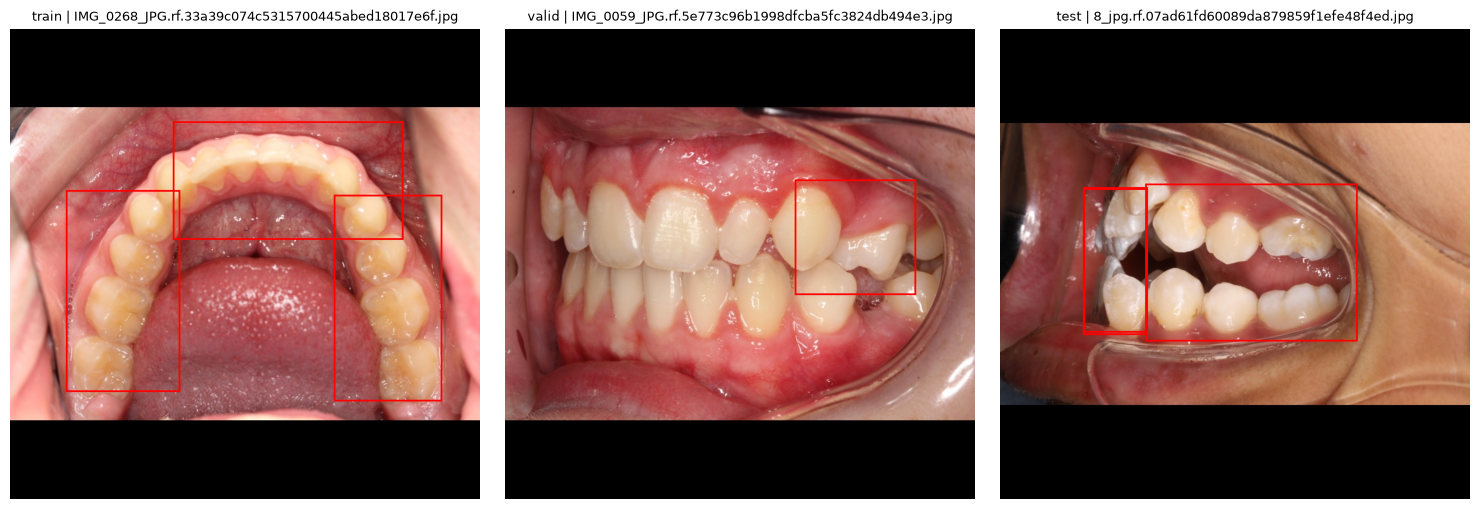

In [9]:
def plot_processed_sample(split, ax):
    with open(DST / split / "_annotations.coco.json") as f:
        d = json.load(f)
    img_rec = d["images"][0]
    img = Image.open(DST / split / img_rec["file_name"]).copy()
    draw = ImageDraw.Draw(img)
    boxes = [a for a in d["annotations"] if a["image_id"] == img_rec["id"]]
    for a in boxes:
        x, y, w, h = a["bbox"]
        draw.rectangle([x, y, x + w, y + h], outline=(255, 0, 0), width=3)
    ax.imshow(img)
    ax.set_title(f"{split} | {img_rec['file_name']}", fontsize=9)
    ax.axis("off")

fig, axes = plt.subplots(1, len(NEW_SPLITS), figsize=(15, 5))
for split, ax in zip(NEW_SPLITS, axes):
    plot_processed_sample(split, ax)
plt.tight_layout()
plt.show()


## 7. Ringkasan

- Dataset baru: `Dataset/Malocclusion-Data-processed/{train,valid,test}/` — struktur COCO standar, siap dipakai `torchvision.datasets.CocoDetection` atau loader COCO lain.
- Split sudah diperbaiki: semua kelas (kecuali `4l`/`5p` yang cuma py 2 instance total — batas matematis) punya representasi di ketiga split.
- Semua gambar seragam 800×800 (letterbox, aspect ratio asli terjaga, padding hitam).
- **Belum ada augmentasi** (flip/rotasi/brightness/dll) — ini dataset "base" untuk percobaan training pertama.
- Dataset asli (`Malocclusion-Data-1/`) tidak diubah/disentuh sama sekali.